In [1]:
import yfinance as yf
import pandas as pd
import os
import stock_load as loader 
import stock_features as features
import stock_strategy as strategy
import matplotlib.pyplot as plt
import stock_backtest as backtest
from stock_pair_search import *

c:\Users\Hello!!!\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Hello!!!\AppData\Local\Programs\Python\Python313\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [2]:
df = loader.load_local_data("data/stock_features_70.csv")

📂 Đang đọc dữ liệu từ đĩa: data/stock_features_70.csv...
✅ Đã đọc dữ liệu thành công.


# Mean Reversion

In [3]:
df_mean_signals = strategy.run_mean_reversion_strategy(df)
if df_mean_signals is not None:
    print("Chiến lược đã được áp dụng thành công.")

🧠 Chạy Mean Reversion (Single Stock)...
Chiến lược đã được áp dụng thành công.


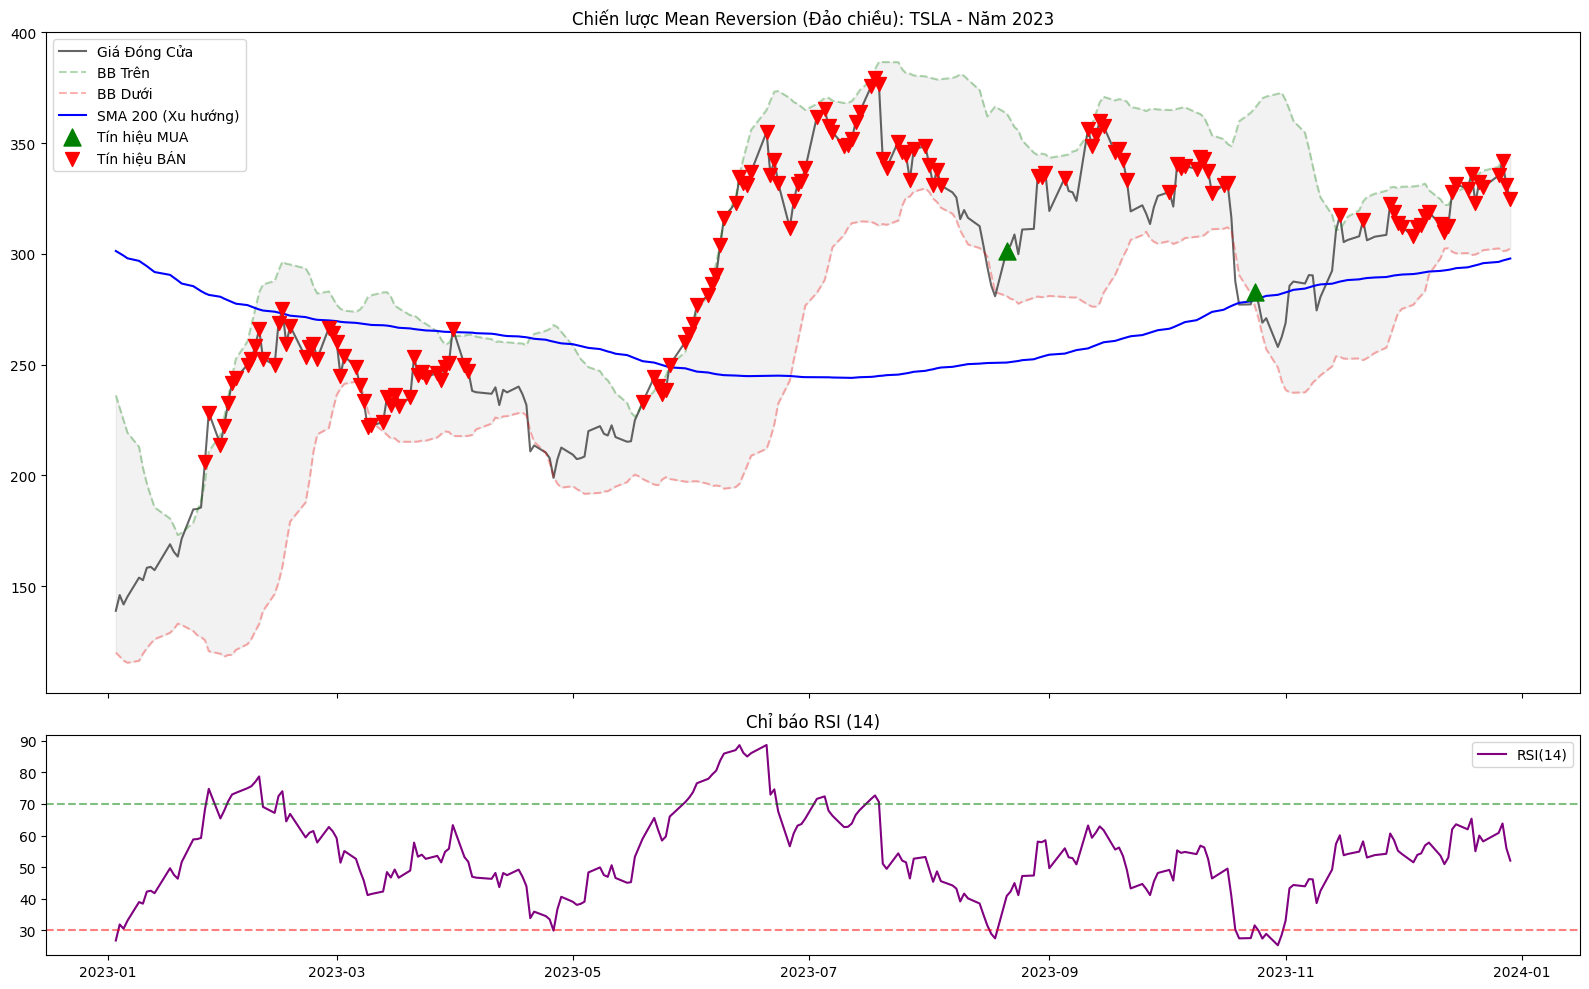

In [4]:
# --- CÀI ĐẶT BIỂU ĐỒ ---
target_ticker = 'TSLA'  # Thử đổi thành MSFT, TSLA...
zoom_year = '2023'      # Năm muốn xem kỹ

# Lấy dữ liệu của mã đó
data_plot = df_mean_signals.xs(target_ticker, level='Ticker')
subset = data_plot.loc[zoom_year]

# --- VẼ BIỂU ĐỒ ---
fig, ax = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# 1. Biểu đồ Giá & Bollinger Bands
ax[0].plot(subset.index, subset['Close'], label='Giá Đóng Cửa', color='black', alpha=0.6)
ax[0].plot(subset.index, subset['BB_Upper'], label='BB Trên', color='green', linestyle='--', alpha=0.3)
ax[0].plot(subset.index, subset['BB_Lower'], label='BB Dưới', color='red', linestyle='--', alpha=0.3)
ax[0].plot(subset.index, subset['SMA_200'], label='SMA 200 (Xu hướng)', color='blue', linewidth=1.5)
ax[0].fill_between(subset.index, subset['BB_Upper'], subset['BB_Lower'], color='gray', alpha=0.1)

# Vẽ mũi tên MUA (Signal = 1)
buy_points = subset[subset['Signal_MR'] == 1]
ax[0].scatter(buy_points.index, buy_points['Close'], marker='^', color='green', s=150, label='Tín hiệu MUA', zorder=5)

# Vẽ mũi tên BÁN/THOÁT (Signal = -1)
sell_points = subset[subset['Signal_MR'] == -1]
ax[0].scatter(sell_points.index, sell_points['Close'], marker='v', color='red', s=100, label='Tín hiệu BÁN', zorder=5)

ax[0].set_title(f"Chiến lược Mean Reversion (Đảo chiều): {target_ticker} - Năm {zoom_year}")
ax[0].legend()

# 2. Biểu đồ RSI
ax[1].plot(subset.index, subset['RSI_14'], color='purple', label='RSI(14)')
ax[1].axhline(30, color='red', linestyle='--', alpha=0.5)
ax[1].axhline(70, color='green', linestyle='--', alpha=0.5)
ax[1].set_title("Chỉ báo RSI (14)")
ax[1].legend()

plt.tight_layout()
plt.show()

## Backtesting 

In [5]:

# Giả sử mỗi mã được cấp 100,000$ vốn ảo để chạy độc lập
res_mr = backtest.run_backtest_mean_reversion(df_mean_signals, initial_capital=10_000)
print("\n--- TOP 5 MÃ MEAN REVERSION ---")
display(res_mr.head(5))

🚀 Backtest Mean Reversion (Risk 3.0%, SL 2.0ATR)...


d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades rema


--- TOP 5 MÃ MEAN REVERSION ---


,Ticker,Net Profit ($),Final Equity ($),Return (%),Win Rate (%),Max Drawdown (%),# Trades
62,UNH,2526.477100,12526.477100,25.264771,86.363636,-3.319071,22
4,AMD,2500.207570,12500.207570,25.002076,73.684211,-3.951606,19
61,TSLA,1042.086565,11042.086565,10.420866,85.714286,-3.330524,14
60,TMUS,994.527950,10994.527950,9.945280,85.000000,-3.126768,20
25,FCX,953.730045,10953.730045,9.537300,80.000000,-3.515042,15


## Đánh giá 

In [6]:
res_mr.describe()

,Net Profit ($),Final Equity ($),Return (%),Win Rate (%),Max Drawdown (%),# Trades
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000
mean,179.908610,10179.908610,1.799086,74.569999,-4.722948,19.104478
std,599.629306,599.629306,5.996293,10.054859,2.897017,4.071834
min,-1300.539934,8699.460066,-13.005399,52.941176,-16.276501,9.000000
25%,-92.882617,9907.117383,-0.928826,67.424242,-5.900133,15.500000
50%,129.477908,10129.477908,1.294779,73.684211,-3.630817,19.000000
75%,385.233767,10385.233767,3.852338,83.333333,-3.000472,22.000000
max,2526.477100,12526.477100,25.264771,100.000000,-1.488452,30.000000


In [7]:
rate = sum(res_mr['Net Profit ($)'])
print("\n--- KẾT QUẢ TỔNG QUÁT CHIẾN LƯỢC MEAN REVERSION : RISK = 3%, cond_trend_exit = BB_Upper, cond_trend_up = True---")
print("Tổng số vốn đầu tư: $", 10_000*70, ",mỗi mã là 10 000$")
print(f"Tổng lợi nhuận từ chiến lược Mean Reversion trên 70 mã: ${round(rate)}")
print(f"Tỷ lệ lợi nhuận: ", rate/(10_000*70)*100,"%")
print(f"Tổng số lệnh đã thực hiện: ", sum(res_mr['# Trades']))
print(f"Tỷ lệ thắng trung bình : ", sum(res_mr['Win Rate (%)'])/70,"%")


--- KẾT QUẢ TỔNG QUÁT CHIẾN LƯỢC MEAN REVERSION : RISK = 3%, cond_trend_exit = BB_Upper, cond_trend_up = True---
Tổng số vốn đầu tư: $ 700000 ,mỗi mã là 10 000$
Tổng lợi nhuận từ chiến lược Mean Reversion trên 70 mã: $12054
Tỷ lệ lợi nhuận:  1.7219824086248976 %
Tổng số lệnh đã thực hiện:  1280
Tỷ lệ thắng trung bình :  71.37414207034901 %




-> Chiến lược chưa hiệu quả , lãi suất thua gửi ngân hàng 

Giải thích :
- SMA_200 : Dùng để hỏi thị trường dài hạn đang tăng hay là đang giảm
- SMA_50 : Dùng để chốt lời, bởi niềm tin mean reversion
- risk = 3% : Mỗi lần giao dịch, chấp nhận rủi ro mất 3% vốn ( bán khi gặp stop loss)

In [8]:
res_mr_1 = backtest.run_backtest_garch_mean_reversion(df_mean_signals, initial_capital=10_000)
print("\n--- TOP 5 MÃ MEAN REVERSION ---")
display(res_mr_1.head(5))

🚀 Backtest GARCH Mean Reversion (Risk 3.0%, SL 2.0xGARCH)...



--- TOP 5 MÃ MEAN REVERSION ---


,Ticker,Net Profit ($),Final Equity ($),Return (%),Win Rate (%),Max Drawdown (%),# Trades
0,AAPL,0.0,10000.0,0.0,NaN,-0.0,0
2,ADBE,0.0,10000.0,0.0,NaN,-0.0,0
5,AMT,0.0,10000.0,0.0,NaN,-0.0,0
4,AMD,0.0,10000.0,0.0,NaN,-0.0,0
9,BA,0.0,10000.0,0.0,NaN,-0.0,0


In [9]:
res_mr_1.describe()
rate = sum(res_mr_1['Net Profit ($)'])
print("\n--- KẾT QUẢ TỔNG QUÁT CHIẾN LƯỢC MEAN REVERSION : RISK = 3%, cond_trend_exit = BB_Upper, cond_trend_up = True---")
print("Tổng số vốn đầu tư: $", 10_000*70, ",mỗi mã là 10 000$")
print(f"Tổng lợi nhuận từ chiến lược Mean Reversion trên 70 mã: ${round(rate)}")
print(f"Tỷ lệ lợi nhuận: ", rate/(10_000*70)*100,"%")
print(f"Tổng số lệnh đã thực hiện: ", sum(res_mr_1['# Trades']))
print(f"Tỷ lệ thắng trung bình : ", sum(res_mr_1['Win Rate (%)'])/70,"%")


--- KẾT QUẢ TỔNG QUÁT CHIẾN LƯỢC MEAN REVERSION : RISK = 3%, cond_trend_exit = BB_Upper, cond_trend_up = True---
Tổng số vốn đầu tư: $ 700000 ,mỗi mã là 10 000$
Tổng lợi nhuận từ chiến lược Mean Reversion trên 70 mã: $-3815
Tỷ lệ lợi nhuận:  -0.5450258749367842 %
Tổng số lệnh đã thực hiện:  144
Tỷ lệ thắng trung bình :  nan %


# Swing Trading 

## Signal, Backtesting

In [10]:
df_swing_signals = strategy.run_swing_strategy(df)
if df_swing_signals is not None:
    print("Chiến lược đã được áp dụng thành công.")
# Giả sử mỗi mã được cấp 100,000$ vốn ảo để chạy độc lập
res_mr = backtest.run_backtest_mean_reversion(df_swing_signals, initial_capital=10_000)
print("\n--- TOP 5 MÃ SWING---")
display(res_mr.head(5))

🧠 Chạy Swing (Single Stock)...
Chiến lược đã được áp dụng thành công.
🚀 Backtest Mean Reversion (Risk 3.0%, SL 2.0ATR)...


d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades rema


--- TOP 5 MÃ SWING---


,Ticker,Net Profit ($),Final Equity ($),Return (%),Win Rate (%),Max Drawdown (%),# Trades
4,AMD,4017.009115,14017.009115,40.170091,63.888889,-18.918764,36
63,UNH,3732.511323,13732.511323,37.325113,75.000000,-8.811323,40
62,TSLA,3268.742295,13268.742295,32.687423,66.666667,-12.401460,36
8,AVGO,3097.511357,13097.511357,30.975114,71.428571,-10.072651,35
50,NVDA,2801.769118,12801.769118,28.017691,75.757576,-12.063803,33


## Đánh giá 

In [11]:
res_mr.describe()

,Net Profit ($),Final Equity ($),Return (%),Win Rate (%),Max Drawdown (%),# Trades
count,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
mean,751.859079,10751.859079,7.518591,67.409500,-8.462875,33.779412
std,1031.507318,1031.507318,10.315073,7.816086,3.946717,5.130667
min,-773.260586,9226.739414,-7.732606,48.275862,-18.918764,19.000000
25%,72.129132,10072.129132,0.721291,62.767857,-10.662124,31.000000
50%,564.927829,10564.927829,5.649278,68.432056,-8.061976,34.000000
75%,1219.590164,11219.590164,12.195902,73.548387,-5.414219,36.250000
max,4017.009115,14017.009115,40.170091,81.578947,-2.565386,47.000000


In [12]:
rate = sum(res_mr['Net Profit ($)'])
print("\n--- KẾT QUẢ TỔNG QUÁT CHIẾN LƯỢC SWING : RISK = 3%, cond_trend_exit = BB_Upper, cond_trend_up = True---")
print("Tổng số vốn đầu tư: $", 10_000*70, ",mỗi mã là 10 000$")
print(f"Tổng lợi nhuận từ chiến lược Swing trên 70 mã: ${round(rate)}")
print(f"Tỷ lệ lợi nhuận: ", rate/(10_000*70)*100,"%")
print(f"Tổng số lệnh đã thực hiện: ", sum(res_mr['# Trades']))
print(f"Tỷ lệ thắng trung bình : ", sum(res_mr['Win Rate (%)'])/70,"%")


--- KẾT QUẢ TỔNG QUÁT CHIẾN LƯỢC SWING : RISK = 3%, cond_trend_exit = BB_Upper, cond_trend_up = True---
Tổng số vốn đầu tư: $ 700000 ,mỗi mã là 10 000$
Tổng lợi nhuận từ chiến lược Swing trên 70 mã: $51126
Tỷ lệ lợi nhuận:  7.303773906564122 %
Tổng số lệnh đã thực hiện:  2297
Tỷ lệ thắng trung bình :  65.48351384684622 %


# Momentum

In [13]:
df_momentum_signals = strategy.run_momentum_strategy(df)
if df_momentum_signals is not None:
    print("Chiến lược đã được áp dụng thành công.")
res_mm= backtest.run_backtest_momentum(df_momentum_signals, initial_capital=10_000)
print("\n--- TOP 5 MÃ MOMENTUM---")
display(res_mm.head(5))
res_mm.describe()


🧠 Chạy Momentum (Top 7)...


d:\stock_strategy.py:86: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_mom.resample('M').last()


Chiến lược đã được áp dụng thành công.
🚀 Backtest Momentum (Rebalancing Top 7)...


d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()
d:\stock_backtest.py:172: UserWarning: Some trades rema


--- TOP 5 MÃ MOMENTUM---


,Ticker,Net Profit ($),Final Equity ($),Return (%),Win Rate (%),Max Drawdown (%),# Trades
50,NVDA,257283.265318,267283.265318,2572.832653,80.000000,-55.724691,5
4,AMD,78592.805685,88592.805685,785.928057,80.000000,-46.000836,5
47,NFLX,36818.500274,46818.500274,368.185003,85.714286,-39.973184,7
8,AVGO,33344.059991,43344.059991,333.440600,50.000000,-56.380015,10
26,GE,25209.203112,35209.203112,252.092031,50.000000,-27.529941,2


,Net Profit ($),Final Equity ($),Return (%),Win Rate (%),Max Drawdown (%),# Trades
count,70.000000,70.000000,70.000000,55.000000,70.000000,70.000000
mean,7717.449609,17717.449609,77.174496,60.991342,-23.416927,2.614286
std,32383.998796,32383.998796,323.839988,32.355842,17.932047,2.311238
min,-2330.725935,7669.274065,-23.307259,0.000000,-63.000662,0.000000
25%,0.000000,10000.000000,0.000000,50.000000,-38.965005,1.000000
50%,588.440348,10588.440348,5.884403,60.000000,-20.978395,2.000000
75%,3053.751262,13053.751262,30.537513,92.857143,-11.419502,4.000000
max,257283.265318,267283.265318,2572.832653,100.000000,-0.000000,10.000000


In [ ]:
res_mm.describe()
rate = sum(res_mm['Net Profit ($)'])
print("\n--- KẾT QUẢ TỔNG QUÁT CHIẾN LƯỢC MEAN REVERSION : RISK = 3%, cond_trend_exit = BB_Upper, cond_trend_up = True---")
print("Tổng số vốn đầu tư: $", 10_000*70, ",mỗi mã là 10 000$")
print(f"Tổng lợi nhuận từ chiến lược Mean Reversion trên 70 mã: ${round(rate)}")
print(f"Tỷ lệ lợi nhuận: ", rate/(10_000*70)*100,"%")
print(f"Tổng số lệnh đã thực hiện: ", sum(res_mm['# Trades']))
print(f"Tỷ lệ thắng trung bình : ", sum(res_mm['Win Rate (%)'])/70,"%")


--- KẾT QUẢ TỔNG QUÁT CHIẾN LƯỢC MEAN REVERSION : RISK = 3%, cond_trend_exit = BB_Upper, cond_trend_up = True---
Tổng số vốn đầu tư: $ 700000 ,mỗi mã là 10 000$
Tổng lợi nhuận từ chiến lược Mean Reversion trên 70 mã: $540221
Tỷ lệ lợi nhuận:  77.17449609329886 %
Tổng số lệnh đã thực hiện:  183
Tỷ lệ thắng trung bình :  nan %


# Pair trading

In [26]:
df_raw = loader.load_local_data("D:\\stock_data_70.csv")

📂 Đang đọc dữ liệu từ đĩa: D:\stock_data_70.csv...
✅ Đã đọc dữ liệu thành công.


In [28]:
# --- BƯỚC 1: CHIA DỮ LIỆU ---
# Dữ liệu mẫu (Formation): Dùng để tìm cặp (Train)
df_train = df_raw.loc[:'2021-01-01'] 

# Dữ liệu kiểm thử (Trading): Dùng để backtest (Test)
df_test = df_raw.loc['2021-01-02':]
print(f"Traing Data (Tìm cặp): {len(df_train)} dòng")
print(f"Testing Data (Giao dịch): {len(df_test)} dòng")

Traing Data (Tìm cặp): 123410 dòng
Testing Data (Giao dịch): 83370 dòng


In [43]:
# Tìm cặp
df_pairs_sector = run_search_by_sector(df_train,csv_path = "D:\\tickers_70.csv")
# Chọn cặp 
if not df_pairs_sector.empty:
    top_pair = df_pairs_sector.iloc[0]
    stock_A = top_pair['Stock A']
    stock_B = top_pair['Stock B']
    print(f"⭐ Cặp được chọn từ quá khứ: {stock_A} - {stock_B}")
if df_pairs_sector.empty:
    print("Không tìm thấy cặp phù hợp.")



--- CHIẾN LƯỢC 2: SECTOR ---
✅ Đã đọc 70 mã từ file CSV.

🔍 Bắt đầu quét Cointegration trong từng nhóm 'Sector'...
Không tìm thấy cặp phù hợp.


d:\stock_pair_search.py:41: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_prices = df_prices.fillna(method='ffill').fillna(method='bfill')


In [ ]:


    # --- BƯỚC 4: BACKTEST TRÊN TẬP TEST ---
    # Quan trọng: Lấy tín hiệu trên tập Test, nhưng dùng Beta của tập Train (hoặc tính lại)
    
    # Cách A: Tính lại Beta và Z-score hoàn toàn trên tập Test (Dynamic)
    # df_signal_test, beta_test = run_pair_strategy(df_test, stock_A, stock_B)
    
    # Cách B: Dùng Beta cũ của tập Train để áp dụng cho tương lai (Strict Out-of-Sample)
    # (Code hiện tại của bạn hàm run_pair_strategy đang tính lại beta trên dữ liệu đầu vào)
    # Nên ta chỉ cần đưa df_test vào là được.
    
    df_signal_test, beta_test = strategy.run_pair_strategy(df_test, stock_A, stock_B)
    
    # Chạy Backtest
    res_pair = backtest.run_backtest_pair(df_test, df_signal_test, stock_A, stock_B, beta_test)


--- CHIẾN LƯỢC 1: CLUSTERING ---
⚙️ Đang phân cụm 70 mã thành 11 nhóm (K-Means)...
   -> Kết quả phân bố các cụm:
Cluster
0      2
1     25
2      4
3     27
4      1
5      3
6      1
7      1
8      4
9      1
10     1
Name: count, dtype: int64

🔍 Bắt đầu quét Cointegration trong từng nhóm 'Cluster'...


d:\stock_pair_search.py:41: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_prices = df_prices.fillna(method='ffill').fillna(method='bfill')
